# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muhammad Ryan Fikri Fakhrezi
- **Email:** ryanfikri5@gmail.com
- **ID Dicoding:** ryanfikri

## Menentukan Pertanyaan Bisnis

- Bagaimana jumlah rental sepeda bervariasi di berbagai kondisi cuaca, dan kondisi cuaca apa yang terkait dengan rata-rata rental tertinggi per hari?
- Pada musim apa terekam rental sepeda tertinggi, dan bagaimana tingkat suhu dan kelembapan selama musim tersebut memengaruhi volume penyewaan?

## Import Semua Packages/Library yang Digunakan

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

Langkah pertama yang saya lakukan adalah memuat semua data yang diperlukan. Saya memuat data didalam day.csv sebagai pandas data frame pada variabel day_df dan data didalam hour.csv pada variabel hour_df

### Gathering Data

In [4]:
day_df = pd.read_csv("data/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
hour_df = pd.read_csv("data/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- file day.csv memuat data sharing sepeda dalam rentang harian
- file hour.csv memuat data sharing sepeda dalam rentang jam-an
- perbedaan dari kedua file ini adalah, pada file day.csv tidak terdapat kolom hr.

### Assessing Data

Langkah berikutnya yang saya lakukan adalah melakukan penilaian terhadap data. Saya memulainya dengan mendapatkan rangkuman dari dataframe menggunakan method info() dari pandas dataframe

In [6]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Insight:**
- Pada semua kolom tidak ada perbedaan jumlah, sehingga tidak ada missing value pada semua kolom
- pada kolom dtday, tipe datanya adalah object, bukan datetime

Berikutnya, saya mengecek duplikasi data menggunakan method duplicated()

In [7]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Tidak terdapat duplikasi data pada file day.csv

Berikutnya, saya mengecek deskriptif statistik dari dataframe day_df menggunakan method describe() untuk mengecek keanehan pada tabel day_df

In [8]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Kolom season dapat bernilai dari 1-4 (1: semi, 2: panas, 3: gugur, 4: dingin)
- Kolom yr dapat bernilai dari 0-1 (0: 2011, 1: 2012)
- Kolom mnth dapat bernilai dari 1-12 (1: Jan, ..., 12: Dec)
- Kolom holiday menyatakan apakah harinya libur atau tidak (0/1)
- kolom weekday menyatakan hari dalam seminggu (0-6)
- kolom workingday bernilai 1 jika dan hanya jika harinya bukan weekend dan bukan hari libur
- kolom weathersit menyatakan cuaca hari itu, bernilai 1-4
    - 1: Cerah, Sedikit awan, Sebagian berawan, Sebagian berawan
	- 2: Kabut + Mendung, Kabut + Awan pecah, Kabut + Sedikit awan, Kabut
	- 3: Salju Ringan, Hujan Ringan + Badai Petir + Awan berserakan, Hujan Ringan + Awan berserakan
	- 4: Hujan Lebat + Hujan Es + Badai Petir + Kabut, Salju + Kabut
- Kolom temp, atemp, hum, dan windspeed sudah ternormalisasi. temp dibagi dengan 41, atemp dibagi dengan 50, hum dibagi dengan 100, dan windspeed dibagi 67
- Kolom casual menyatakan jumlah pengguna kasual
- Kolom registered menyatakan jumlah pengguna yang terregistrasi
- Kolom cnt = casual + registered
- Tidak terdapat keanehan nilai pada tabel ini

Kemudian untuk memastikan bahwa data didalam kolom cnt tidak ada yang salah, saya mengeceknya dengan membandingkan nilai cnt dengan casual+registered

In [9]:
is_correct = (day_df['cnt'] == day_df['casual'] + day_df['registered'])

if is_correct.all():
    print("Semua data cnt benar")
else:
    print("Data yang salah:")
    print(day_df[~is_correct])

Semua data cnt benar


**Insight:**
- Tidak ada baris dengan data 'cnt' yang salah

Kemudian, saya berganti ke dataframe hour_df untuk melanjutkan proses penilaian. Saya memulainya dengan mendapatkan rangkuman dataframe hour_df menggunakan method info()

In [10]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**Insight**
- Pada semua kolom tidak ada perbedaan jumlah, sehingga tidak ada missing value pada semua kolom
- pada kolom dtday, tipe datanya adalah object, bukan datetime

Kemudian, saya lanjutkan dengan mengecek duplikasi data pada dataframe hour_df menggunakan method duplicated()

In [11]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Tidak terdapat duplikasi data pada file hour.csv

Berikutnya, saya mengecek deskriptif statistik dari dataframe hour_df menggunakan method describe() untuk mengecek keanehan pada tabel hour_df

In [12]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Kolom season dapat bernilai dari 1-4 (1: semi, 2: panas, 3: gugur, 4: dingin)
- Kolom yr dapat bernilai dari 0-1 (0: 2011, 1: 2012)
- Kolom mnth dapat bernilai dari 1-12 (1: Jan, ..., 12: Dec)
- Kolom hr menyatakan jam dalam satu hari (0-23)
- Kolom holiday menyatakan apakah harinya libur atau tidak (0/1)
- kolom weekday menyatakan hari dalam seminggu (0-6)
- kolom workingday bernilai 1 jika dan hanya jika harinya bukan weekend dan bukan hari libur
- kolom weathersit menyatakan cuaca hari itu, bernilai 1-4
    - 1: Cerah, Sedikit awan, Sebagian berawan, Sebagian berawan
	- 2: Kabut + Mendung, Kabut + Awan pecah, Kabut + Sedikit awan, Kabut
	- 3: Salju Ringan, Hujan Ringan + Badai Petir + Awan berserakan, Hujan Ringan + Awan berserakan
	- 4: Hujan Lebat + Hujan Es + Badai Petir + Kabut, Salju + Kabut
- Kolom temp, atemp, hum, dan windspeed sudah ternormalisasi. temp dibagi dengan 41, atemp dibagi dengan 50, hum dibagi dengan 100, dan windspeed dibagi 67
- Kolom casual menyatakan jumlah pengguna kasual
- Kolom registered menyatakan jumlah pengguna yang terregistrasi
- Kolom cnt = casual + registered
- Tidak terdapat keanehan nilai pada tabel ini

Kemudian untuk memastikan bahwa data didalam kolom cnt tidak ada yang salah, saya mengeceknya dengan membandingkan nilai cnt dengan casual+registered

In [13]:
is_correct = (hour_df['cnt'] == hour_df['casual'] + hour_df['registered'])

if is_correct.all():
    print("Semua data cnt benar")
else:
    print("Data yang salah:")
    print(hour_df[~is_correct])

Semua data cnt benar


**Insight:**
- Tidak ada baris dengan data 'cnt' yang salah

### Cleaning Data

Langkah ketiga yang saya lakukan adalah melakukan pembersihan data frame sebelum melakukan EDA. langkah pertama yang saya lakukan adalah dengan mengubah tipe data pada kolom 'dteday' menjadi datetime, baik pada day_df maupun pada hour_df

In [14]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [15]:
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Tipe data untuk kolom "dteday" sudah benar

## Exploratory Data Analysis (EDA)

Setelah proses pembersihan data, saya lanjut melakukan EDA pada dataframe yang sudah bersih. Saya memulainya dengan melihat deskriptif statistik pada day_df dan melihat informasi apa saja yang dapat diperoleh

### Explore day_df

In [16]:
day_df.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


**Insight:**
- cuacanya cenderung Cerah, Sedikit awan, atau Berawan sebagian
- rata-rata suhunya berada di 20.310785°C
- rata-rata kelembapan berada di 62.7894

Kemudian saya melihat distribusi jumlah rental pada setiap musimnya

In [17]:
day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                                
         max   min         mean          std
season                                      
1       7836   431  2604.132597  1399.942119
2       8362   795  4992.331522  1695.977235
3       8714  1115  5644.303191  1459.800381
4       8555    22  4728.162921  1699.615261

**Insight:**
- Jumlah rental sepeda cenderung tinggi pada musim gugur dan cenderung rendah pada musim panas. 
- Jumlah rental sepeda terendah terekam pada musim dingin dan jumlah rental sepeda tertinggi terekam pada musim gugur

Setelah melihat distribusi jumlah rental pada setiap musim, saya  mencoba melihat distribusinya pada setiap cuaca

In [18]:
day_df.groupby(by="weathersit").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                               
             max  min         mean          std
weathersit                                     
1           8714  431  4876.786177  1879.483989
2           8362  605  4035.862348  1809.109918
3           4639   22  1803.285714  1240.284449

**Insight:**
- Di data tidak pernah terekam kondisi cuaca nomor 4 (Hujan Lebat + Palet Es + Badai Petir + Kabut, Salju + Kabut) yang mendominasi dalam 1 hari
- Jumlah rental sepeda cenderung tinggi ketika cuaca Cerah, Sedikit awan, Berawan sebagian
- Jumlah rental sepeda cenderung rendah ketika cuaca Salju Ringan, Hujan Ringan + Badai Petir + Awan yang tersebar, Hujan Ringan + Awan yang tersebar

Setelah mendapatkan insight pada dataframe day_df, saya melakukan hal yang sama pada dataframe hour_df

In [19]:
hour_df.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


Kemudian, saya mengecek nilai max, min, mean, dan standard deviasi dari kolom cnt yang di groupby berdasarkan musimnya

In [20]:
hour_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                            
        max min        mean         std
season                                 
1       801   1  111.114569  119.224010
2       957   1  208.344069  188.362473
3       977   1  236.016237  197.711630
4       967   1  198.868856  182.967972

**Insight:**
- Jumlah rental sepeda cenderung tinggi pada musim gugur dan cenderung rendah pada musim panas. 
- Jumlah rental sepeda terendah terekam pada musim dingin dan jumlah rental sepeda tertinggi terekam pada musim gugur

In [21]:
hour_df.groupby(by="weathersit").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                            
            max min        mean         std
weathersit                                 
1           977   1  204.869272  189.487773
2           957   1  175.165493  165.431589
3           891   1  111.579281  133.781045
4           164  23   74.333333   77.925178

**Insight:**
- Jumlah rental sepeda cenderung tinggi ketika cuaca Cerah, Sedikit awan, Berawan sebagian
- Jumlah rental sepeda cenderung rendah ketika cuaca Hujan Lebat + Palet Es + Badai Petir + Kabut, Salju + Kabut

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana jumlah rental sepeda bervariasi di berbagai kondisi cuaca, dan kondisi cuaca mana yang terkait dengan rata-rata penyewaan tertinggi per hari?

Untuk menjawab pertanyaan pertama, saya memulainya dengan melakukan groupby pada salah satu dataframe dengan variabel weathersit

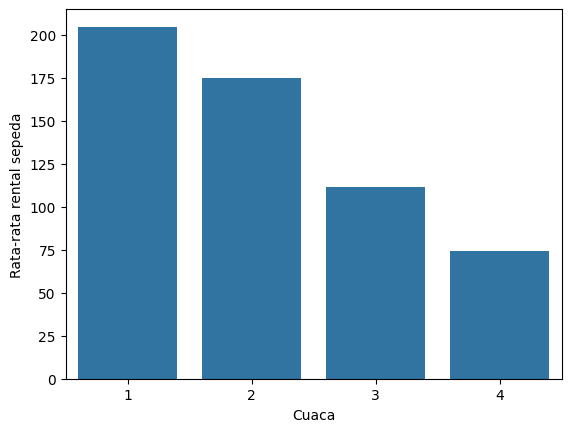

In [32]:
grouped_data = hour_df.groupby(by='weathersit').agg({
    "cnt": "mean"
})

sns.barplot(x='weathersit', y='cnt', data=grouped_data)
plt.xlabel('Cuaca')
plt.ylabel('Rata-rata rental sepeda')
plt.show()

**Insight:**
- Pada visualisasi tersebut, saya dapat melihat bahwa cuaca 1 (Clear, Few clouds, Partly cloudy, Partly cloudy) cenderung memiliki jumlah rental yang tinggi, diikuti oleh cuaca 2, 3, dan 4.

Untuk menjawab bagaimana jumlah rental dapat bervariasi di berbagai kondisi cuaca, saya melihat hubungan antara berbagai parameter cuaca dengan jumlah rental sepeda

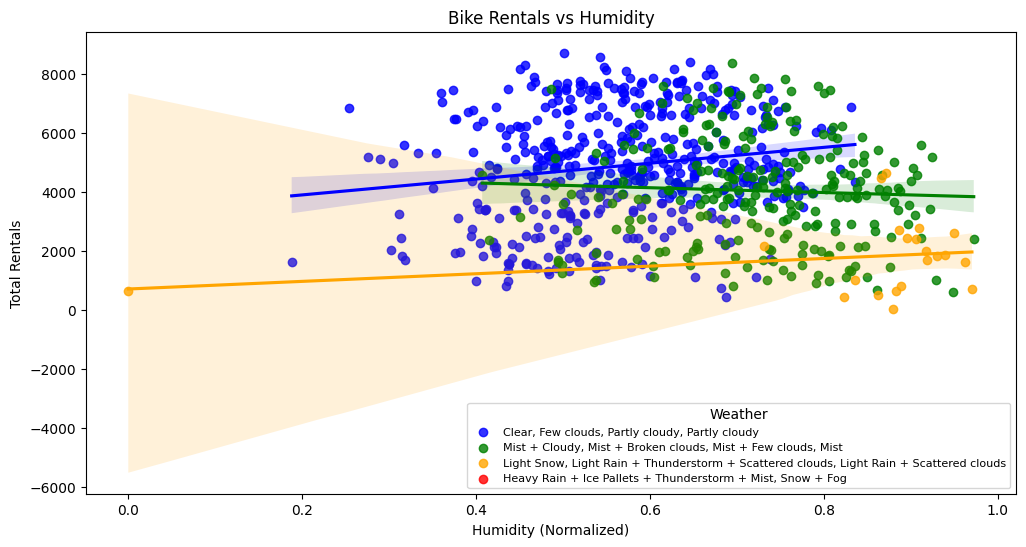

In [23]:
weather_colors = {1: 'blue', 2: 'green', 3: 'orange', 4: 'red'}
weather_labels = {1: 'Clear, Few clouds, Partly cloudy, Partly cloudy', 
                 2: 'Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist', 
                 3: 'Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds', 
                 4: 'Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog'
                 }

plt.figure(figsize=(12, 6))

for weather in [1, 2, 3, 4]:
    sns.regplot(
        x='hum', 
        y='cnt', 
        data=day_df[day_df['weathersit'] == weather], 
        scatter_kws={'color': weather_colors[weather], 'label': weather_labels[weather]}, 
        line_kws={"color": weather_colors[weather]},
        label = weather_labels[weather]
    )

# sns.regplot(x='hum', y='cnt', data=day_df[day_df['season'] == 4], line_kws={"color":"red"})
plt.title('Bike Rentals vs Humidity')
plt.xlabel('Humidity (Normalized)')
plt.ylabel('Total Rentals')
plt.legend(title="Weather", loc='lower right', fontsize=8)
plt.show()

**Insight:**
- Pada cuaca 1&3 tingkat kelembaban cenderung berbanding lurus dengan jumlah rental, sedangkan pada cuaca 4 tingkat kelembaban cenderung tidak terlalu berpengaruh dengan jumlah rental

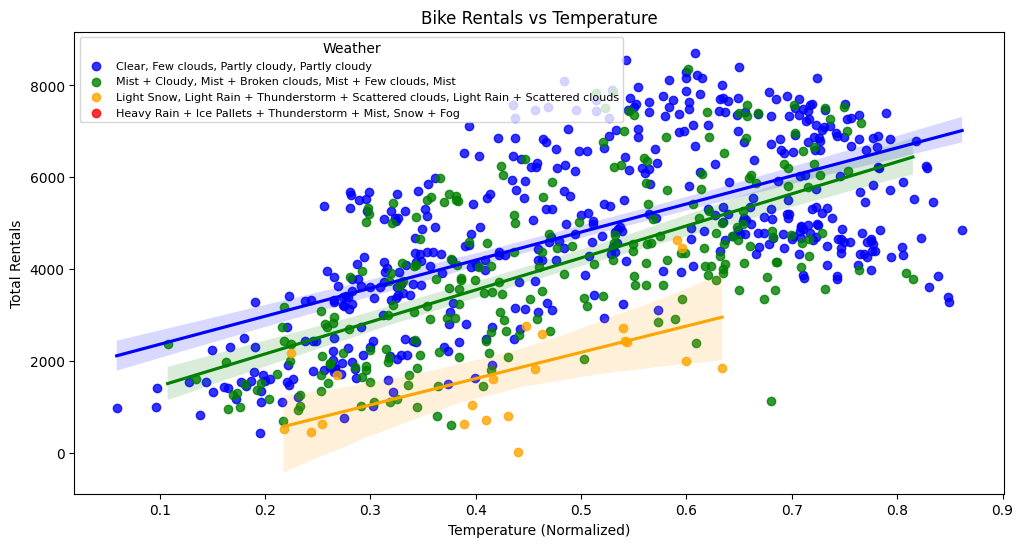

In [24]:
weather_colors = {1: 'blue', 2: 'green', 3: 'orange', 4: 'red'}
weather_labels = {1: 'Clear, Few clouds, Partly cloudy, Partly cloudy', 
                 2: 'Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist', 
                 3: 'Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds', 
                 4: 'Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog'
                 }

plt.figure(figsize=(12, 6))

for weather in [1, 2, 3, 4]:
    sns.regplot(
        x='temp', 
        y='cnt', 
        data=day_df[day_df['weathersit'] == weather], 
        scatter_kws={'color': weather_colors[weather], 'label': weather_labels[weather]}, 
        line_kws={"color": weather_colors[weather]},
        label = weather_labels[weather]
    )

# sns.regplot(x='hum', y='cnt', data=day_df[day_df['season'] == 4], line_kws={"color":"red"})
plt.title('Bike Rentals vs Temperature')
plt.xlabel('Temperature (Normalized)')
plt.ylabel('Total Rentals')
plt.legend(title="Weather", loc='upper left', fontsize=8)
plt.show()

**Insight:**
- Pada setiap cuaca, jumlah rental berbanding lurus dengan peningkatan temperatur

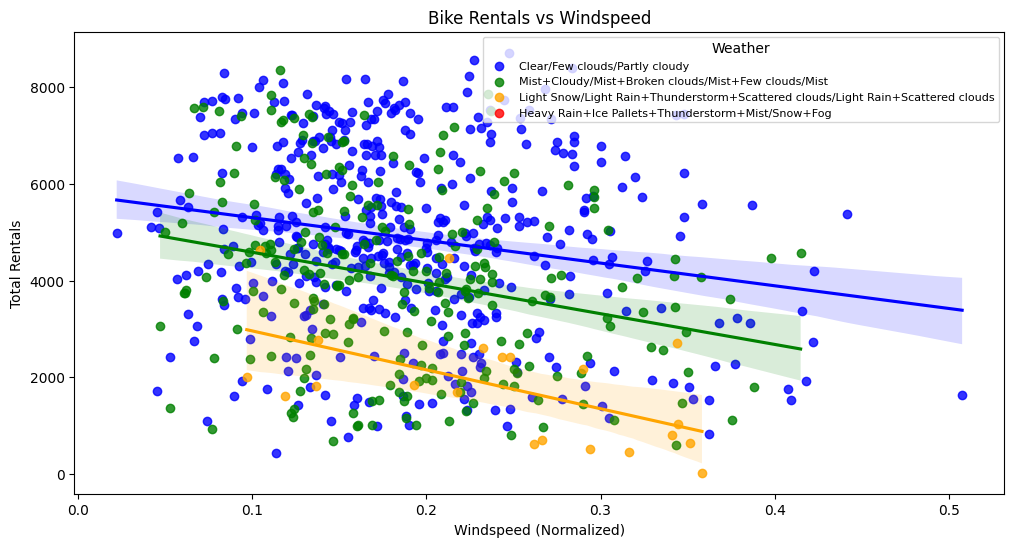

In [25]:
weather_colors = {1: 'blue', 2: 'green', 3: 'orange', 4: 'red'}
weather_labels = {1: 'Clear/Few clouds/Partly cloudy', 
                 2: 'Mist+Cloudy/Mist+Broken clouds/Mist+Few clouds/Mist', 
                 3: 'Light Snow/Light Rain+Thunderstorm+Scattered clouds/Light Rain+Scattered clouds', 
                 4: 'Heavy Rain+Ice Pallets+Thunderstorm+Mist/Snow+Fog'
                 }

plt.figure(figsize=(12, 6))

for weather in [1, 2, 3, 4]:
    sns.regplot(
        x='windspeed', 
        y='cnt', 
        data=day_df[day_df['weathersit'] == weather], 
        scatter_kws={'color': weather_colors[weather], 'label': weather_labels[weather]}, 
        line_kws={"color": weather_colors[weather]},
        label = weather_labels[weather]
    )

plt.title('Bike Rentals vs Windspeed')
plt.xlabel('Windspeed (Normalized)')
plt.ylabel('Total Rentals')
plt.legend(title="Weather", loc='upper right', fontsize=8)
plt.show()

**Insight:**
- Pada setiap cuaca, jumlah rental terlihat berbanding terbalik dengan tingkat kecepatan angin

Dari visualisasi diatas, terlihat bahwa berbagai parameter cuaca memiliki korelasi yang cukup signifikan dengan jumlah rental, terlebih untuk parameter temperatur dan kecepatan angin

### Pertanyaan 2: Pada musim apa terekam rental sepeda tertinggi, dan bagaimana tingkat suhu dan kelembapan selama musim tersebut memengaruhi volume penyewaan?

Untuk menjawab pertanyaan diatas, saya akan memulainya dengan melakukan groupby pada day_df untuk melihat musim apa yang memiliki tingkat rental sepeda tertinggi

In [26]:
day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                                
         max   min         mean          std
season                                      
1       7836   431  2604.132597  1399.942119
2       8362   795  4992.331522  1695.977235
3       8714  1115  5644.303191  1459.800381
4       8555    22  4728.162921  1699.615261

**Insight:**
- Musim gugur memiliki tingkat rata-rata jumlah rental tertinggi

Kemudian, untuk menjawab pertanyaan bagian kedua, saya mencoba melihat korelasi antara berbagai parameter cuaca terhadap jumlah rental

In [27]:
peak_season_data = day_df[day_df['season'] == 3]
correlation_matrix = peak_season_data[['cnt', 'temp', 'atemp', 'hum', 'windspeed']].corr()
print(correlation_matrix)

                cnt      temp     atemp       hum  windspeed
cnt        1.000000 -0.032819 -0.073841 -0.320252  -0.200191
temp      -0.032819  1.000000  0.877178 -0.376983  -0.039520
atemp     -0.073841  0.877178  1.000000 -0.286174  -0.060143
hum       -0.320252 -0.376983 -0.286174  1.000000   0.021321
windspeed -0.200191 -0.039520 -0.060143  0.021321   1.000000


**Insight:**
- semua parameter berbanding terbalik dengan jumlah rental dengan parameter humidity memiliki tingkat korelasi tertinggi disusul oleh windspeed, feeling temperature, dan temperature
- temperature dan feeling temperature memiliki korelasi positif yang besar

Kemudian saya melihat grafik regresi antara setiap parameter cuaca dengan jumlah rental pada musim gugur

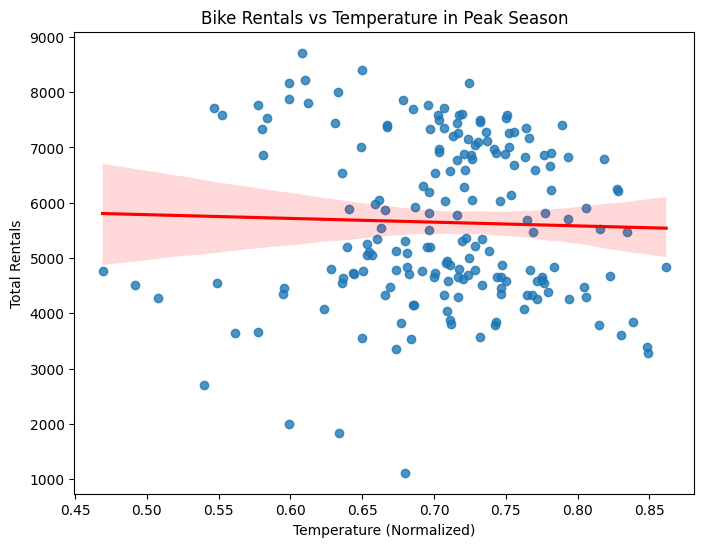

In [28]:
plt.figure(figsize=(8, 6))
sns.regplot(x='temp', y='cnt', data=peak_season_data, line_kws={"color":"red"})
plt.title('Bike Rentals vs Temperature in Peak Season')
plt.xlabel('Temperature (Normalized)')
plt.ylabel('Total Rentals')
plt.show()

**Insight:**
- Temperatur tidak terlalu berpengaruh dengan jumlah rental

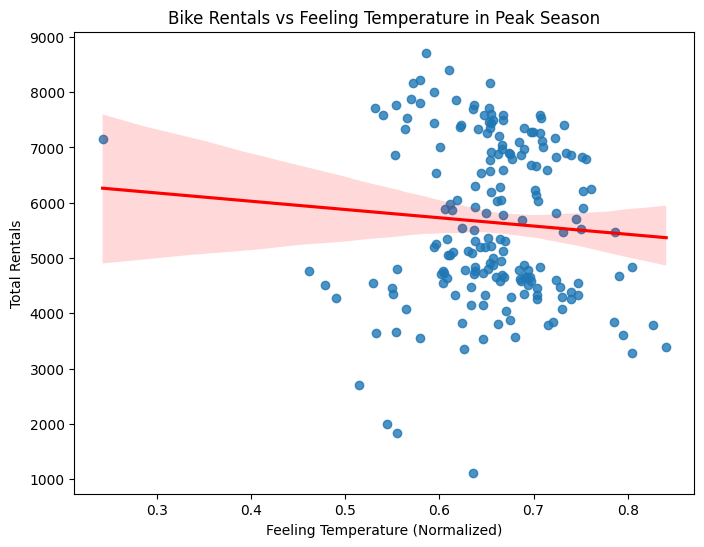

In [29]:
plt.figure(figsize=(8, 6))
sns.regplot(x='atemp', y='cnt', data=peak_season_data, line_kws={"color":"red"})
plt.title('Bike Rentals vs Feeling Temperature in Peak Season')
plt.xlabel('Feeling Temperature (Normalized)')
plt.ylabel('Total Rentals')
plt.show()

**Insight:**
- Feeling temperature cenderung berbanding terbalik dengan jumlah rental

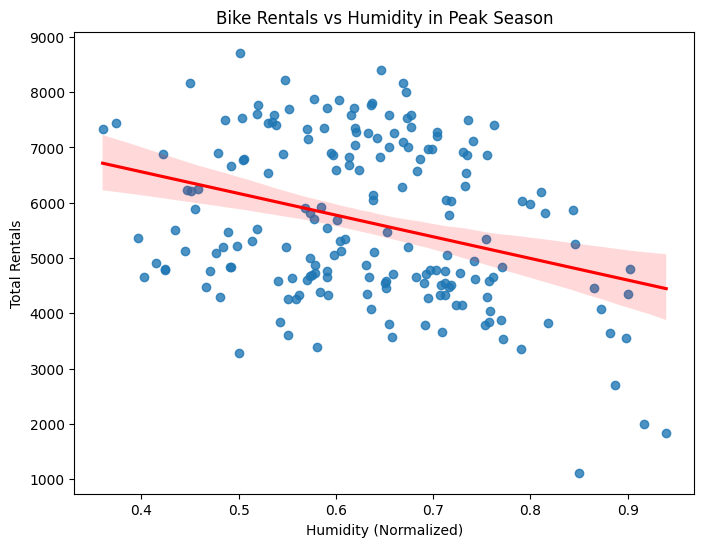

In [30]:
plt.figure(figsize=(8, 6))
sns.regplot(x='hum', y='cnt', data=peak_season_data, line_kws={"color":"red"})
plt.title('Bike Rentals vs Humidity in Peak Season')
plt.xlabel('Humidity (Normalized)')
plt.ylabel('Total Rentals')
plt.show()

**Insight:**
- jumlah rental sepeda cenderung berbanding terbalik dengan tingkat kelembaban

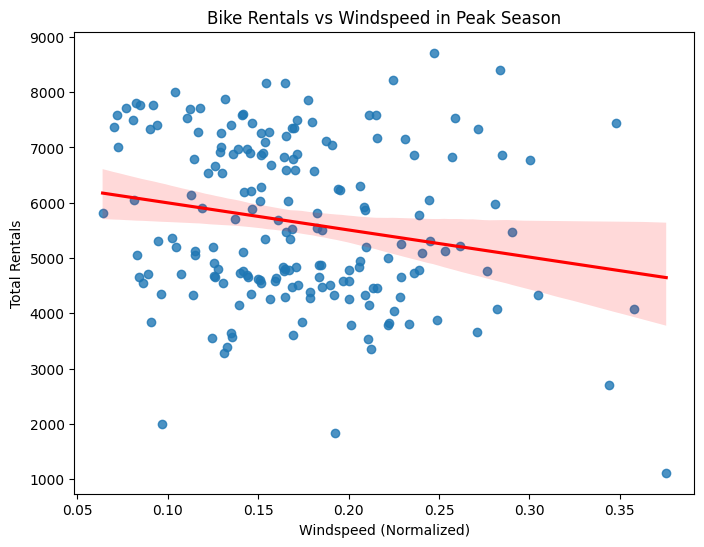

In [31]:
plt.figure(figsize=(8, 6))
sns.regplot(x='windspeed', y='cnt', data=peak_season_data, line_kws={"color":"red"})
plt.title('Bike Rentals vs Windspeed in Peak Season')
plt.xlabel('Windspeed (Normalized)')
plt.ylabel('Total Rentals')
plt.show()

**Insight:**
- Jumlah rental cenderung berbanding terbalik dengan kecepatan angin

## Conclusion

- Jumlah rental sepeda cukup bervariasi untuk setiap kondisi cuaca, dengan jumlah tertinggi terjadi pada cuaca 1 (Cerah, Sedikit awan, Berawan sebagian, Berawan sebagian) dan jumlah terendah terjadi pada cuaca 4 (Hujan Lebat + Palet Es + Badai Petir + Kabut, Salju + Kabut)
- Jumlah rental sepeda tertinggi terjadi pada musim gugur, dan jumlah rental ini berbanding terbalik dengan temperatur, kelembaban, dan kecepatan angin. Semakin tinggi temperatur/kelembaban/kecepatan angin maka jumlah rental sepeda akan cenderung semakin rendah